provided by cbi  
https://github.com/cbi-society/cheminfo_tutorial_20241028_pub/tree/main

subprocess.callで実行する場合、存在するtomlファイルを指定すればreinventは実行できる。
1. tomlファイルをsubprocess.callで編集できれば実行できる
2. tomlファイルをつくらずに実行できればなおよい

# 変数処理のテスト

In [1]:
import subprocess

In [2]:
test='''
this is a test
hello world from python and terminal
'''

In [3]:
subprocess.call([
    'echo',
     test
     ])


this is a test
hello world from python and terminal



0

In [50]:
random='''
run_type = "sampling"
device = "mps"  # set torch device e.g. "cpu". For macOS, use "mps"
json_out_config = "_sampling.json"  # write this TOML to JSON

## Reinvent: de novo sampling
model_file = "User/keetane/Documents/apps/REINVENT4/priors/reinvent.prior"
output_file = 'sampling.csv'  # sampled SMILES and NLL in CSV format

num_smiles = 157  # number of SMILES to be sampled, 1 per input SMILES
unique_molecules = true  # if true remove all duplicatesd canonicalize smiles
randomize_smiles = true # if true shuffle atoms in SMILES randomly

'''
subprocess.call(['cat', random])


cat: 
run_type = "sampling"
device = "mps"  # set torch device e.g. "cpu". For macOS, use "mps"
json_out_config = "_sampling.json"  # write this TOML to JSON

## Reinvent: de novo sampling
model_file = "User/keetane/Documents/apps/REINVENT4/priors/reinvent.prior"
output_file = 'sampling.csv'  # sampled SMILES and NLL in CSV format

num_smiles = 157  # number of SMILES to be sampled, 1 per input SMILES
unique_molecules = true  # if true remove all duplicatesd canonicalize smiles
randomize_smiles = true # if true shuffle atoms in SMILES randomly

: No such file or directory


1

In [51]:
subprocess.call(['echo', random])


run_type = "sampling"
device = "mps"  # set torch device e.g. "cpu". For macOS, use "mps"
json_out_config = "_sampling.json"  # write this TOML to JSON

## Reinvent: de novo sampling
model_file = "User/keetane/Documents/apps/REINVENT4/priors/reinvent.prior"
output_file = 'sampling.csv'  # sampled SMILES and NLL in CSV format

num_smiles = 157  # number of SMILES to be sampled, 1 per input SMILES
unique_molecules = true  # if true remove all duplicatesd canonicalize smiles
randomize_smiles = true # if true shuffle atoms in SMILES randomly




0

# REINVENT4の実行

## Working Directoryとpathの設定

temporary directoryをworking directoryに設定する。

import libraries

In [4]:
import os
import shutil

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import reinvent
from reinvent.notebooks import load_tb_data, plot_scalars, get_image, create_mol_grid

%load_ext tensorboard

In [5]:
!pwd

/Users/keetane/Documents/infomatics


set working directory

In [11]:
import os
import shutil

# ホームディレクトリの下に新しい作業ディレクトリを作成する例
R_dir = os.path.expanduser("~/Documents/apps/REINVENT4")
wd = os.path.join(R_dir, "tmp") # 例：~/MyJupyterProject
os.makedirs(wd, exist_ok=True) # ディレクトリが存在しない場合は作成

shutil.rmtree(os.path.join(wd, "R4_notebooks_output"), ignore_errors=True) # 以前のディレクトリを削除 (もしあれば)
wd_new = os.path.join(wd, "R4_notebooks_output")
os.makedirs(wd_new, exist_ok=True)
os.chdir(wd_new)
print(os.getcwd())

/Users/keetane/Documents/apps/REINVENT4/tmp/R4_notebooks_output


In [12]:
R_dir

'/Users/keetane/Documents/apps/REINVENT4'

set parameter file path

In [13]:
reinvent = "/Users/keetane/opt/anaconda3/envs/r4/bin/reinvent"
priors_dir = os.path.join(R_dir, "priors")
Reinvent = os.path.join(priors_dir, "reinvent.prior")
Reinvent

'/Users/keetane/Documents/apps/REINVENT4/priors/reinvent.prior'

In [ ]:
lib = os.path.join(priors_dir, "libinvent.prior")
link = os.path.join(priors_dir, "linkinvent.prior")
mol2mol_high = os.path.join(priors_dir, "mol2mol_high_similarity.prior")
mol2mol_med = os.path.join(priors_dir, "mol2mol_medium_similarity.prior")
mol2mol_mmp = os.path.join(priors_dir, "mol2mol_mmp.prior")
mol2mol_scaffold_generic= os.path.join(priors_dir, "mol2mol_scaffold_generic.prior")
mol2mol_scaffold = os.path.join(priors_dir, "mol2mol_scaffold.prior")
mol2mol_similarity = os.path.join(priors_dir, "mol2mol_similarity.prior")
pubchem = os.path.join(priors_dir, "pubchem_ecfp4_with_count_with_rank_reinvent4_dict_voc.prior")
sampling = os.path.join(priors_dir, "reinvent.prior")

In [8]:
toml=f'''
run_type = "sampling"
device = "mps"  # set torch device e.g. "cpu". For macOS, use "mps"
json_out_config = "_sampling.json"  # write this TOML to JSON

## Reinvent: de novo sampling
model_file = "{Reinvent}"
output_file = 'sampling.csv'  # sampled SMILES and NLL in CSV format

num_smiles = 157  # number of SMILES to be sampled, 1 per input SMILES
unique_molecules = true  # if true remove all duplicatesd canonicalize smiles
randomize_smiles = true # if true shuffle atoms in SMILES randomly
'''

toml_config_filename = "toml.toml"

with open(toml_config_filename, "w") as f:
    f.write(toml)
os.listdir()
os.getcwd()

'/private/tmp/R4_notebooks_output'

In [71]:
!pwd

/private/tmp/R4_notebooks_output


In [ ]:
toml=f'''
# REINVENT4 TOML input example for sampling
#


run_type = "sampling"
device = "mps"  # set torch device e.g. "cpu". For macOS, use "mps"
json_out_config = "_sampling.json"  # write this TOML to JSON


[parameters]

# Uncomment one of the comment blocks below.  Each generator needs a model
# file and possibly a SMILES file with seed structures.

## Reinvent: de novo sampling
model_file = "priors/reinvent.prior"

## LibInvent: find R-groups for the given scaffolds
#model_file = "priors/libinvent.prior"
#smiles_file = "configs/toml/scaffolds.smi"  # 1 scaffold per line with attachment points

## LinkInvent: find a linker/scaffold to link two fragments
#model_file = "priors/linkinvent.prior"
#smiles_file = "configs/toml/warheads.smi"  # 2 warheads per line separated with '|'

## Mol2Mol: find molecules similar to the provided molecules
#model_file = "priors/mol2mol_medium_similarity.prior"
#smiles_file = "mol2mol.smi"  # 1 compound per line
#sample_strategy = "beamsearch"  # multinomial or beamsearch (deterministic)
#temperature = 1.0 # temperature in multinomial sampling
#tb_logdir = "tb_logs"  # name of the TensorBoard logging directory

output_file = 'results/sampling.csv'  # sampled SMILES and NLL in CSV format

num_smiles = 157  # number of SMILES to be sampled, 1 per input SMILES
unique_molecules = true  # if true remove all duplicatesd canonicalize smiles
randomize_smiles = true # if true shuffle atoms in SMILES randomly

'''

toml_config_filename = "sampling.toml"

with open(toml_config_filename, "w") as tf:
    tf.write(toml)
!cat {toml_config_filename}


# REINVENT4 TOML input example for sampling
#


run_type = "sampling"
device = "mps"  # set torch device e.g. "cpu". For macOS, use "mps"
json_out_config = "_sampling.json"  # write this TOML to JSON


[parameters]

# Uncomment one of the comment blocks below.  Each generator needs a model
# file and possibly a SMILES file with seed structures.

## Reinvent: de novo sampling
model_file = "priors/reinvent.prior"

## LibInvent: find R-groups for the given scaffolds
#model_file = "priors/libinvent.prior"
#smiles_file = "configs/toml/scaffolds.smi"  # 1 scaffold per line with attachment points

## LinkInvent: find a linker/scaffold to link two fragments
#model_file = "priors/linkinvent.prior"
#smiles_file = "configs/toml/warheads.smi"  # 2 warheads per line separated with '|'

## Mol2Mol: find molecules similar to the provided molecules
#model_file = "priors/mol2mol_medium_similarity.prior"
#smiles_file = "mol2mol.smi"  # 1 compound per line
#sample_strategy = "beamsearch"  # multinomial 

In [31]:
!ls

TL.log        sampling.toml


In [32]:
subprocess.call([
    reinvent,
    '-l',
    'TL.log',
    'sampling.toml',
    ])


Traceback (most recent call last):
  File "/Users/keetane/opt/anaconda3/envs/r4/bin/reinvent", line 8, in <module>
    sys.exit(main())
  File "/Users/keetane/opt/anaconda3/envs/r4/lib/python3.10/site-packages/reinvent/Reinvent.py", line 334, in main
    runner(
  File "/Users/keetane/opt/anaconda3/envs/r4/lib/python3.10/site-packages/reinvent/runmodes/samplers/run_sampling.py", line 55, in run_sampling
    adapter, _, model_type = create_adapter(agent_model_filename, "inference", device)
  File "/Users/keetane/opt/anaconda3/envs/r4/lib/python3.10/site-packages/reinvent/runmodes/create_adapter.py", line 30, in create_adapter
    dict_filename = resolve_model_filename(dict_filename)
  File "/Users/keetane/opt/anaconda3/envs/r4/lib/python3.10/site-packages/reinvent/runmodes/create_adapter.py", line 81, in resolve_model_filename
    raise RuntimeError(msg)
RuntimeError: model file /private/tmp/R4_notebooks_output/priors/reinvent.prior is not accessible


1

In [49]:
subprocess.call([
    "/Users/keetane/opt/anaconda3/envs/r4/bin/reinvent",
    "-l",
    "TL.log",
    "/Users/keetane/Documents/cheminfo_tutorial_20241028/data/genai/transfer_learning.toml"
    ])

|          |00:00
Epoch 300: |##########|02:00
0it [02:00, ?it/s]


0

# Reinvent4を使いEGFR kinase阻害剤様の構造生成モデルを作成する

転移学習とSamplingを利用してEGFR kinase阻害剤様の構造生成モデルを作成しましょう。

注）reinvent4は以下のようにCLIで利用しますが、本ハンズオンではjupyter上で実行するためsubprocessを利用します。

```bash
$ reinvent -l log.txt config.toml
```

## 転移学習に利用するEGFR kinase阻害剤の構造を確認する

rdkitを利用して構造を描画し確認します。

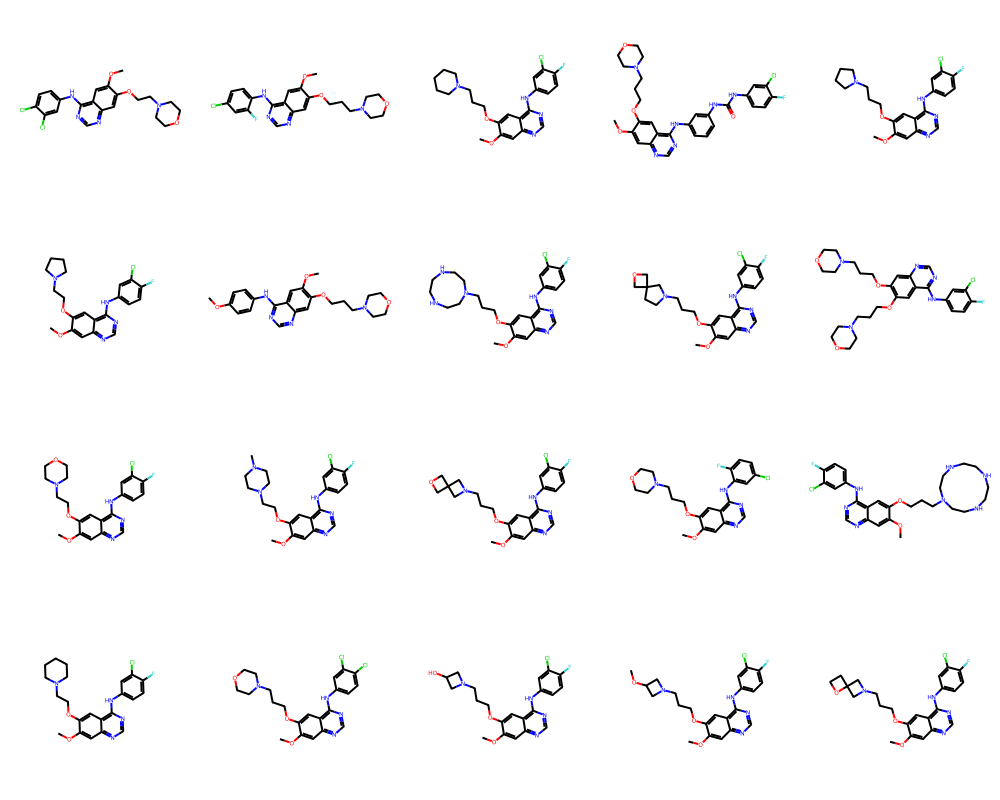

In [1]:
from rdkit import Chem
from rdkit.Chem import Draw
import pandas as pd
df = pd.read_csv('../data/genai/ChEMBL_EGFR.csv')
df.head(2)
Draw.MolsToGridImage([Chem.MolFromSmiles(smi) for smi in df.smiles][:20], molsPerRow=5)

## 設定ファイル(toml)を編集する

../data/genai/ 以下にTomlファイルがありますので、各自の環境に応じて編集をしてください。
以下に今回の転移学習で利用するファイル(transfer_learning.toml)を出力しますが、書き換える必要のある変数は

- device: cudaの場合はcuda:0, MacOS(M1,M2,M3)のgpuの場合はmps, gpuを利用しない場合はcpuを指定してください
- input_model_file, smiles_file, output_model_file, validation_smiles_fileは書き換える必要があります
- 今回はnum_epocを300にしていますがCPUのみの場合は学習に時間がかかるかもしれません。その場合は100に変更してください

In [2]:
!cat ../data/genai/transfer_learning.toml

# REINVENT4 TOML input example for transfer learning
#
# Focus a given model towards a set of input SMILES.  This can also be used to
# start from scratch from and an untrained prior.


run_type = "transfer_learning"
device = "mps"  # set torch device e.g. "cpu"
tb_logdir = "tb_TL"  # name of the TensorBoard logging directory
json_out_config = "json_transfer_learning.json"  # write this TOML to JSON


[parameters]

num_epochs = 300  # number of steps to run
save_every_n_epochs = 3  # save checkpoint model file very N steps
batch_size = 50
num_refs = 5  # number of reference molecules randomly chosen for similarity
                # set this to zero for large datasets (>200 molecules)!
sample_batch_size = 100  # number of sampled molecules to compute sample loss
# Uncomment one of the comment blocks below.  Each generator needs a model
# file and possibly a SMILES file with seed structures.

## Reinvent
#以下をご自身の環境に合わせて書き換えて下さい
#input_model_file = "/home/iwatobipen/dev/REINVENT4/priors/r

## 転移学習を実施
reinventコマンドは各自の環境に依存しますので設定してください

注）仮想環境のpathを調べたい場合は以下のコマンドを実行してください

```bash
$ % conda info --envs
```

In [3]:
import subprocess

In [13]:
%ls /Users/keetane/Documents/cheminfo_tutorial_20241028/data/genai

ChEMBL_EGFR.csv         sampling.toml
TL_sampling.toml        transfer_learning.toml


In [5]:
subprocess.call(
    ["/Users/keetane/opt/anaconda3/envs/r4/bin/reinvent", "-l", "TL.log", "../data/genai/transfer_learning.toml"]
)

|          |00:00
Epoch 300: |##########|01:56
0it [01:56, ?it/s]


0

## tensroboardでログを確認
tensorboardはReinvent4と同じ環境下にインストールされているので、以下のコマンドを実行するとwebブラウザから転移学習の結果を確認することができます。

In [6]:
!/home/iwatobipen/miniforge3/envs/reinvent4/bin/tensorboard --logdir tb_TL/

zsh:1: no such file or directory: /home/iwatobipen/miniforge3/envs/reinvent4/bin/tensorboard


##　訓練前後のモデルでサンプリング（構造生成）

ここでは、転移学習前後の生成モデルから構造生成を行い、EGFR阻害剤様の構造が出力されているか確認します。
転移学習と同様にtomlファイルを設定する必要があります。

sampling.tomlは転移学習前の生成モデルからのサンプリングで、TL_sampling.tomlは転移学習後の生成モデルからのサンプリング用の設定ファイルです。
編集が必要な箇所はdevice,model_fileです。


In [7]:
!cat ../data/genai/sampling.toml

# REINVENT4 TOML input example for sampling
#


run_type = "sampling"
device = "cuda:0"  # set torch device e.g. "cpu"
json_out_config = "_sampling.json"  # write this TOML to JSON


[parameters]

# Uncomment one of the comment blocks below.  Each generator needs a model
# file and possibly a SMILES file with seed structures.

## Reinvent: de novo sampling
model_file = "/home/iwatobipen/dev/REINVENT4/priors/reinvent.prior"

## LibInvent: find R-groups for the given scaffolds
#model_file = "priors/libinvent.prior"
#smiles_file = "scaffolds.smi"  # 1 scaffold per line with attachment points

## LinkInvent: find a linker/scaffold to link two fragments
#model_file = "priors/linkinvent.prior"
#smiles_file = "warheads.smi"  # 2 warheads per line separated with '|'

## Mol2Mol: find molecules similar to the provided molecules
#model_file = "priors/mol2mol_medium_similarity.prior"
#smiles_file = "mol2mol.smi"  # 1 compound per line
#sample_strategy = "beamsearch"  # multinomial or beamsearch (

In [5]:
#訓練前のモデル
subprocess.call(
    ["/Users/keetane/opt/anaconda3/envs/r4/bin/reinvent", "-l", "sampling.log", "../data/genai/sampling.toml"]
)

0

In [9]:
!cat ../data/genai/TL_sampling.toml

# REINVENT4 TOML input example for sampling
#


run_type = "sampling"
device = "cuda:0"  # set torch device e.g. "cpu"
json_out_config = "_TL_sampling.json"  # write this TOML to JSON


[parameters]

# Uncomment one of the comment blocks below.  Each generator needs a model
# file and possibly a SMILES file with seed structures.

## Reinvent: de novo sampling
model_file = "/home/iwatobipen/dev/CBI/cheminfo_tutorial_20241028/notebook/models/TL_reinvent.model"

## LibInvent: find R-groups for the given scaffolds
#model_file = "priors/libinvent.prior"
#smiles_file = "scaffolds.smi"  # 1 scaffold per line with attachment points

## LinkInvent: find a linker/scaffold to link two fragments
#model_file = "priors/linkinvent.prior"
#smiles_file = "warheads.smi"  # 2 warheads per line separated with '|'

## Mol2Mol: find molecules similar to the provided molecules
#model_file = "priors/mol2mol_medium_similarity.prior"
#smiles_file = "mol2mol.smi"  # 1 compound per line
#sample_strategy = "beamse

In [7]:
#訓練後のモデル
subprocess.call(
    ["/Users/keetane/opt/anaconda3/envs/r4/bin/reinvent", "-l", "TL_sampling.log", "../data/genai/TL_sampling.toml"]
)

0

## 構造を確認する

転移学習前後で生成モデルの出力する構造を確認します。転移学習後の生成モデルからはキナゾリン骨格が多く生成されていることを確認してください。

In [8]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import PandasTools

In [9]:
df1 = pd.read_csv('sampling.csv')
print(df1.shape)
df1.tail(2)

(157, 2)


,SMILES,NLL
155,Cn1c(-c2cnc(Oc3cc4ccccc4c(Cl)c3F)c(C#N)c2)n[nH...,43.46
156,c1coc(=NCCN=c2[nH]cnc3c2CCN(Cc2ccsc2)CC3)[nH]1,30.33


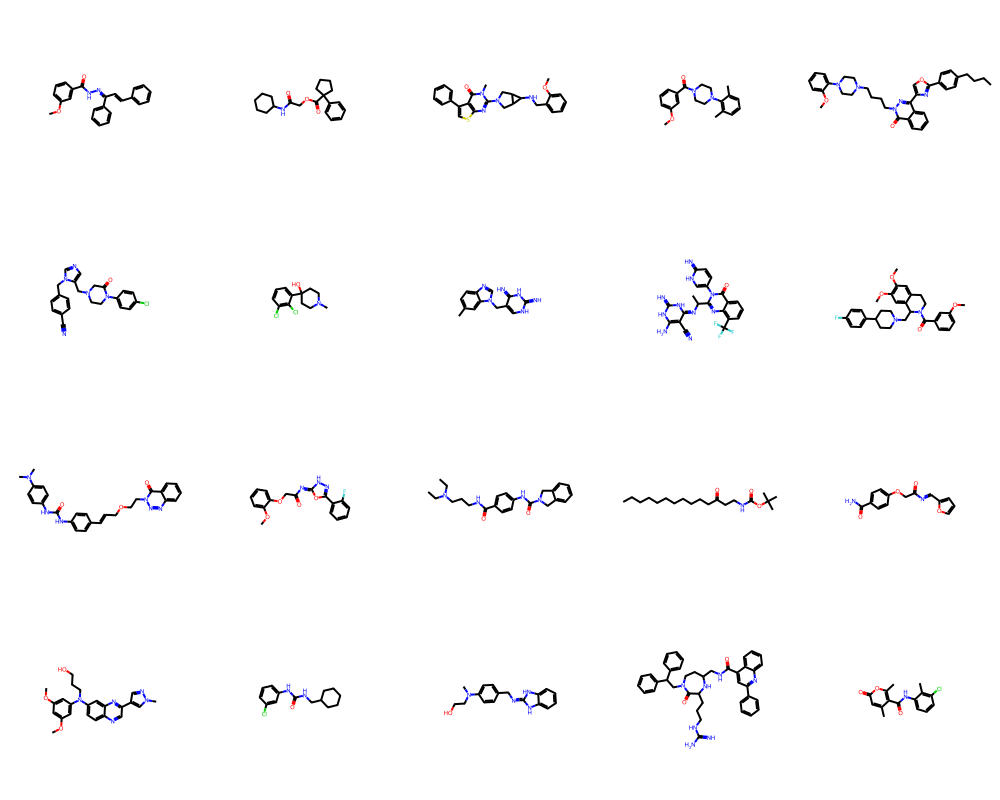

In [10]:
PandasTools.AddMoleculeColumnToFrame(df1, smilesCol='SMILES')
Draw.MolsToGridImage(df1.ROMol[:20], molsPerRow=5)

In [11]:
df2= pd.read_csv('TL_sampling.csv')
print(df2.shape)
df2.tail(2)

(28, 2)


,SMILES,NLL
26,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCC1CNCCO1,18.23
27,Cc1cc(Nc2ccc(F)c(Cl)c2)ncn1,14.26


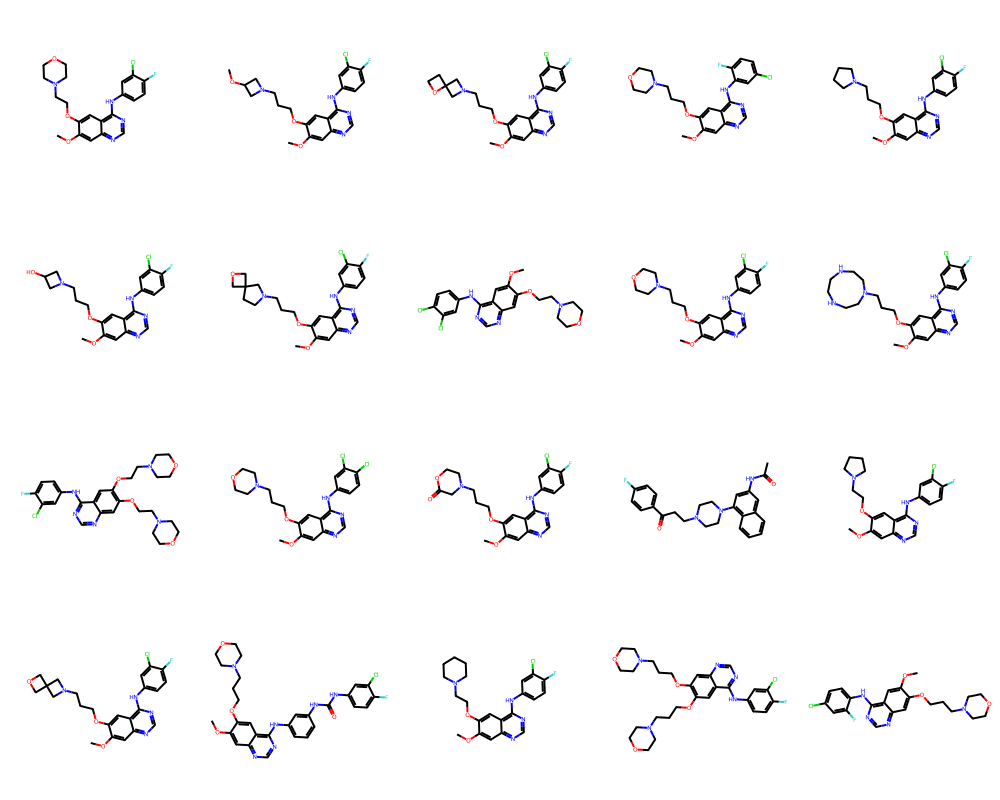

In [12]:
PandasTools.AddMoleculeColumnToFrame(df2, smilesCol='SMILES')
Draw.MolsToGridImage(df2.ROMol[:20], molsPerRow=5)

In [16]:
PandasTools.WriteSDF(df2, 'TL_sampling.sdf', molColName='ROMol', properties=['SMILES'])